<a href="https://colab.research.google.com/github/lordoffatcats/TOL403G/blob/notebooks/T%C3%96L403G_Lokaverkefni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Innlestur á gögnum
Hér eru gögnin (.tsv skrárnar) lesnar inn, og breytt í form sem hægt er að vinna með.

In [1]:
import pandas as pd
!git clone https://github.com/lordoffatcats/TOL403G.git

Cloning into 'TOL403G'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
Receiving objects: 100% (13/13), 140.92 KiB | 4.27 MiB/s, done.
remote: Total 13 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (2/2), done.


Inntakið er stefnt net af Íslandi, hver hnútur $v$ táknar mót tveggja vega og hefur auðkenni og staðsetningu, $(x, y)$ hnit og breiddar- og lengdargráður ($x, y$ hnitin eru betri upp á að teikna gögnin og reikna fjarlægð (í metrum) en lat/lon til að bera saman við úttak úr t.d. Google maps).

Leggirnir $(u, v)$ tákna vegi, þ.e. það er hægt að keyra á frá $u$ til $v$ og á milli þessara hnúta er ekki hægt að taka neinar aðrar ákvarðanir í umferðinni.

Skráin `nodes.tsv` inniheldur upplýsingar um hnútana, `edges.tsv` inniheldur upplýsingar
um vegina.

## 1.1 Innlestur gagna með Pandas

In [17]:
nodes = pd.read_table('TOL403G/nodes.tsv')
edges = pd.read_table('TOL403G/edges.tsv')
charging = pd.read_table('TOL403G/charging.tsv')

In [18]:
# Sanity check
#display(nodes.head(5))
display(edges.head(100))
#display(charging.head(5))

,u,v,length,name,highway,maxspeed_kph,oneway
0,0,2682,1948.768,Reykjanesbraut,trunk,90.0,1
1,1,3,18.992,Hlíðartorg,trunk,60.0,1
2,1,1658,653.666,Reykjanesbraut,trunk,60.0,1
3,2,1801,423.640,Reykjanesbraut,trunk,90.0,1
4,2,2678,208.144,NaN,trunk_link,50.0,1
...,...,...,...,...,...,...,...
95,50,641,252.921,Vesturlandsvegur,trunk,80.0,1
96,51,1557,42.712,Hakið,secondary,NaN,1
97,51,45,535.571,Hakið,secondary,NaN,0
98,52,587,379.111,Hafnarfjarðarvegur,primary,80.0,1


## 1.2 Uppsetning á neti
Byrjum á að setja upp netið sem grannalista á forminu:

```yaml
hnútur1: [(granni1, þyngd), (granni2, þyngd), ...],
hnútur2: ...,
...
```

*(Við notum grannalista frekar en Grannafylki því að tímaflækja Dijkstra með fylki er $\mathcal{O}(|V|^2)$, en með lista fæst $\mathcal{O}(|E|\log |V|)$)*

In [22]:
net = {node_id: [] for node_id in nodes["id"]}

for u, v, w, oneway in zip(
    edges["u"], edges["v"], edges["length"], edges["oneway"]
):
    net[u].append((v, w))
    if not oneway:
        net[v].append((u, w))

# sanity check
for i in range(10):
    print(net[i])

[(2682, 1948.768)]
[(3, 18.992), (1658, 653.666)]
[(1801, 423.64), (2678, 208.144)]
[(12, 8.737)]
[(10, 14.669)]
[(550, 242.714), (14, 27.836)]
[(1947, 245.206), (1946, 186.31)]
[(1237, 2896.73)]
[(2046, 233.096), (0, 483.358)]
[(1241, 257.243), (7, 482.499)]


# 2. Reiknirit Dijkstra
Útfærum reiknirit Dijkstra sem tekur inn tvo hnúta og finnur stystu leið milli tveggja hnúta.

Reiknirit Dijkstra er eftirfarandi:

1. Búum til mengi af öllum óheimsóttum hnútum.
2. Gefum hverjum hnút upphafsfjarlægð frá byrjunarhnút. $0$ fyrir upphafshnútinn og $\infty$ fyrir alla hina, þar sem við þekkjum ekki neina leið að þeim.
3. Veljum hnútinn úr óheimsótta menginu, sem hefur lægstu endanlegu fjarlægð. Í upphafi verður þetta upphafshnúturinn. Ef mengið er tómt eða allir hnútar hafa $\infty$ fjarlægð, þá stoppum við og förum í skref 6. Ef markmiðið er eingöngu leiðin að ákveðnum hnút $v$ stoppum við þegar valdi hnúturinn er $v$. Annars, þá höldum við áfram.
4. Fyrir valda hnútinn $u_i$, þá skoðum við alla óheimsótta nágranna hans og uppfærum fjarlægðir útfrá $u_i$. Þ.e. ef fjarlægðin að nágranna er styttri frá $u_i$, þá breytum við fjarlægðinni í þá lægri.
5. Eftir að allir óheimsóttir nágrannar $u_i$ eru uppfærðir, þá er $u_i$ fjarlægður úr óheimsótta menginu.
6. Þegar lykkjunni í skrefum 3-5 er lokið, þá innihalda allir heimsóttir hnútar stystu vegalengd frá byrjunarhnút.

Við útfærum mengið af óheimsóttum hnútum sem min-hrúgu með `heapq`, þar sem lyklarnir eru fjarlægðirnar og gildin eru hnútar.

In [25]:
import heapq

def dijkstra(G, startnode, endnode):
    """ Notar reiknirit Dijkstra til að finna stystu leið milli tveggja hnúta.
    Inntak:
        G: Net táknað sem grannalisti. Á forminu Dict[int, List[Tuple[int, float]]].
        startnode: id á upphafshnút í netinu
        endnode: id á endahnút í netinu.
    Úttak:
        E: [Listi eða sambærilegt] af leggjum sem mynda stysta veg á milli hnúta startnode og endnode
    """
    distances = {node: float("inf") for node in G}
    distances[startnode] = 0.0

    heap = [(0.0, startnode)]

    while heap:
        current_dist, u = heapq.heappop(heap)

        if current_dist > distances[u]:
            continue

        for v, weight in G[u]:
            new_dist = current_dist + weight

            if new_dist < distances[v]:
                distances[v] = new_dist
                heapq.heappush(heap, (new_dist, v))
            if v == endnode:
                break;
    return distances

In [26]:
dijkstra(net, 0, 100)

{0: 0.0,
 1: 10584.111,
 2: 11758.418000000001,
 3: 10603.103000000001,
 4: 10631.052,
 5: 11672.949000000002,
 6: 9584.701000000001,
 7: 27394.373000000003,
 8: 23562.515999999996,
 9: 26911.874000000003,
 10: 10645.721,
 11: 11629.993000000002,
 12: 10611.84,
 13: 10536.966,
 14: 11560.678000000002,
 15: 37194.74600000001,
 16: 37808.528000000006,
 17: 517520.79699999996,
 18: 405045.16099999985,
 19: 405129.07399999985,
 20: 463387.8,
 21: 407866.88899999997,
 22: 601654.1149999999,
 23: 470035.459,
 24: 597107.8869999999,
 25: 22034.37599999999,
 26: 268208.87,
 27: 24072.78999999999,
 28: 438157.78799999994,
 29: 22732.14799999999,
 30: 560764.626,
 31: 20223.791000000005,
 32: 20728.68,
 33: 334542.86,
 34: 34689.61799999999,
 35: 36170.448999999986,
 36: 36366.92699999999,
 37: 38874.77999999999,
 38: 41575.791,
 39: 44572.738999999994,
 40: 423083.59699999995,
 41: 8434.419999999998,
 42: 8409.012999999999,
 43: 9271.183,
 44: 8345.435,
 45: 60703.37900000001,
 46: 28671.696000

# 3. Mynd af netinu


<Axes: xlabel='lon', ylabel='lat'>

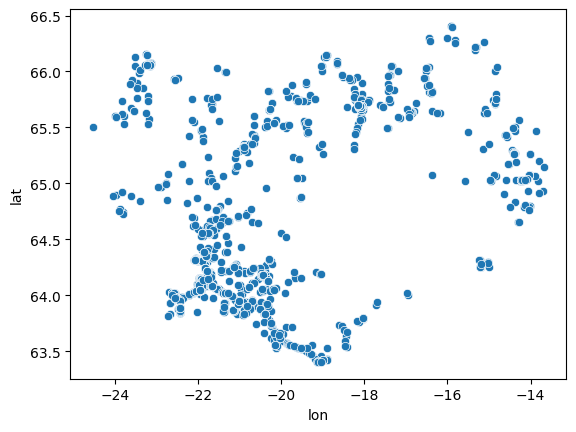

In [27]:
import seaborn as sns
sns.scatterplot(nodes, x='lon', y='lat')